# Benchmark 4: Heterogeneous density with a discontinuity

- *Authors*: Danilo Aballay and Elwin van 't Wout
- *Affiliation*: Pontificia Universidad Católica de Chile
- *Date:* 26 May 2026
- *Description*: This benchmark considers a cubic scatterer with a heterogeneous material density with a jump across interfaces. The numerical results from the VSIE and BEM are compared..

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from benchmarks import VSIE_solve, fembem_solve
from parameters import PARAMETERS

INFO:bempp:Numba backend activated. For full performance the OpenCL backend with an OpenCL CPU driver is required.


In [2]:
def matrix_linf_norm(vec, shape):
    return np.linalg.norm(np.real(vec).reshape(shape), ord=np.inf)

def run_benchmark(parameters, element_per_wavelength=8, err=False):
    pressure_vie, problem = VSIE_solve(element_per_wavelength, parameters, err=err)
    

    n_vox = round(problem.mesh.shape[0]**(1/3))
    points3D = problem.mesh.reshape((n_vox, n_vox, n_vox, 3))
    slice = points3D[:, :, n_vox//2, :]
    points = slice.reshape((-1, 3))
    pressure_vie3D = pressure_vie.reshape((n_vox, n_vox, n_vox))
    pressure_vie_slice = pressure_vie3D[:, :, n_vox//2].reshape((-1,))

    pressure_bempp =  fembem_solve(element_per_wavelength, parameters, points.T, err=err)

    error_bempp_l2 = np.linalg.norm(np.real(pressure_bempp))
    error_bempp_linf = matrix_linf_norm(pressure_bempp, (n_vox, n_vox))

    error_abs_l2 = np.linalg.norm(np.real(pressure_vie_slice) - np.real(pressure_bempp))
    error_abs_linf = matrix_linf_norm(np.real(pressure_vie_slice) - np.real(pressure_bempp), (n_vox, n_vox))


    error_rel_l2 = error_abs_l2 / error_bempp_l2
    error_rel_linf = error_abs_linf / error_bempp_linf

    data = {
        'solution_vie': pressure_vie_slice,
        'solution_bempp': pressure_bempp,
        'error_abs_l2': error_abs_l2,
        'error_abs_linf': error_abs_linf,
        'error_rel_l2': error_rel_l2,
        'error_rel_linf': error_rel_linf,
        'Nx': n_vox,
        'Ny': n_vox,
        'Nz': n_vox,
        'points': points,
    }

    return data

## Single benchmark

Let us perform a single benchmark with a fixed number of elements per wavelength.

In [3]:
"""
Singular test
"""

data_benchmark = run_benchmark(PARAMETERS, element_per_wavelength=10)


FEM dofs: 117649
Interior BEM dofs: 13826
Exterior BEM dofs: 8212


INFO:root:running build_ext
INFO:root:building 'libffcx_forms_7a5f9a3145827503e9377fc9dfea80f9ec6704f8' extension
INFO:root:clang -Wno-unused-result -Wsign-compare -Wunreachable-code -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /opt/anaconda3/envs/fembem2/include -arch arm64 -fPIC -O2 -isystem /opt/anaconda3/envs/fembem2/include -arch arm64 -I/opt/anaconda3/envs/fembem2/lib/python3.10/site-packages/ffcx/codegeneration -I/opt/anaconda3/envs/fembem2/include/python3.10 -c libffcx_forms_7a5f9a3145827503e9377fc9dfea80f9ec6704f8.c -o ./libffcx_forms_7a5f9a3145827503e9377fc9dfea80f9ec6704f8.o -O2 -g0
INFO:root:clang -bundle -undefined dynamic_lookup -Wl,-rpath,/opt/anaconda3/envs/fembem2/lib -L/opt/anaconda3/envs/fembem2/lib -Wl,-rpath,/opt/anaconda3/envs/fembem2/lib -L/opt/anaconda3/envs/fembem2/lib ./libffcx_forms_7a5f9a3145827503e9377fc9dfea80f9ec6704f8.o -o ./libffcx_forms_7a5f9a3145827503e9377fc9dfea80f9ec6704f8.cpython-310-darwin.so
ld: warning: duplicate -rpath '/opt/anaconda3/envs/fe

  cmap=plt.cm.get_cmap('seismic'),



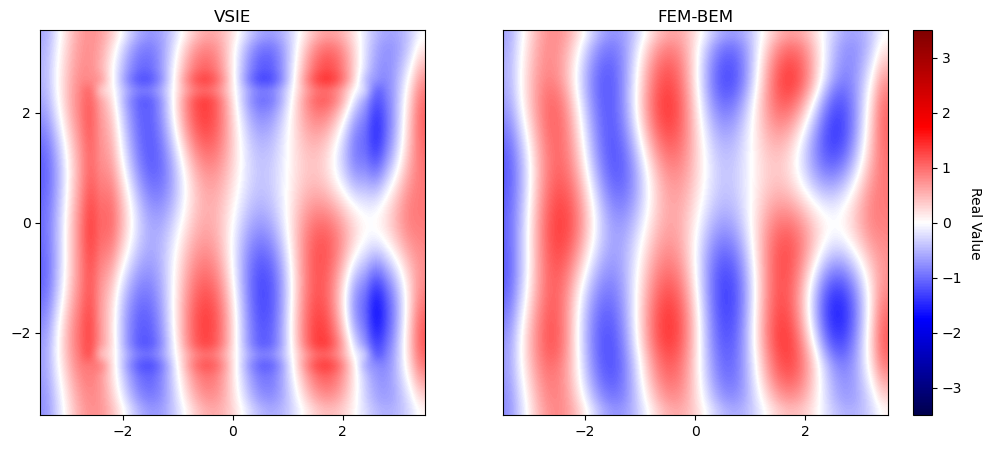

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13,5))

xmin, xmax, ymin, ymax = -PARAMETERS["SIZE_EXT"]/2, PARAMETERS["SIZE_EXT"]/2, -PARAMETERS["SIZE_EXT"]/2, PARAMETERS["SIZE_EXT"]/2
l_cube = PARAMETERS["SIZE_INT"]/2

Nx = data_benchmark['Nx']
Ny = data_benchmark['Ny']

bem_sol = data_benchmark['solution_bempp'].reshape((Nx, Ny))
vie_sol = data_benchmark['solution_vie'].reshape((Nx, Ny))

info_plot_re = [
    (axs[1], "FEM-BEM", np.real((bem_sol).T[::-1]), [-3.5, 3.5]),
    (axs[0], "VSIE", np.real((vie_sol).T[::-1]), [-3.5, 3.5]),
]


for (ax, title, data, clims) in info_plot_re:
    ax.set_title(title)
    im = ax.imshow(data,
              extent=[xmin, xmax, ymin, ymax],
              cmap=plt.cm.get_cmap('seismic'), 
              interpolation='spline16',
              clim=clims)
    ax.set_aspect('equal')

axs[1].get_yaxis().set_visible(False)
# axs[0].get_yaxis().

my_ticks = np.array([-2, 0, 2])

axs[0].set_xticks(my_ticks)
axs[1].set_xticks(my_ticks)
axs[0].set_yticks(my_ticks)
    
cbar = axs[1].figure.colorbar(im, ax=axs[1])
cbar.ax.set_ylabel('Real Value', rotation=-90, va="bottom")



plt.subplots_adjust(wspace=0, hspace=0)

In [6]:
print("Relative L2 error: ", data_benchmark['error_rel_l2'])
print("Relative Linf error: ", data_benchmark['error_rel_linf'])

Relative L2 error:  0.07124266166354094
Relative Linf error:  0.12777696734327826


## Convergence test

Let us perform a grid convergence test. Depending on computational resources, this may take minutes until hours. Eliminate or add experiments to the list of `elements_per_wavelength`.

In [7]:
"""
Convergence test
"""

elements_per_wavelength = [6, 7, 8, 9, 10]

data_convergence = defaultdict(list)

for element_per_wavelength in elements_per_wavelength:
    data_benchmark = run_benchmark(PARAMETERS, element_per_wavelength=element_per_wavelength, err=True)
    data_convergence['element_per_wavelength'].append(element_per_wavelength)
    data_convergence['N_elem'].append(data_benchmark['Nx'])
    data_convergence['error_rel_l2'].append(data_benchmark['error_rel_l2'])
    data_convergence['error_rel_linf'].append(data_benchmark['error_rel_linf'])
    print(f"Done with element_per_wavelength = {element_per_wavelength}")


FEM dofs: 9261
Interior BEM dofs: 2402
Exterior BEM dofs: 1634


  solver = solver_interface(actual_mat)



Done with element_per_wavelength = 6

FEM dofs: 15625
Interior BEM dofs: 3458
Exterior BEM dofs: 2088


  solver = solver_interface(actual_mat)



Done with element_per_wavelength = 7

FEM dofs: 21952
Interior BEM dofs: 4376
Exterior BEM dofs: 2831


...

Done with element_per_wavelength = 8

FEM dofs: 29791
Interior BEM dofs: 5402
Exterior BEM dofs: 3466


  solver = solver_interface(actual_mat)



Done with element_per_wavelength = 9

FEM dofs: 42875
Interior BEM dofs: 6938
Exterior BEM dofs: 4090


  solver = solver_interface(actual_mat)



Done with element_per_wavelength = 10


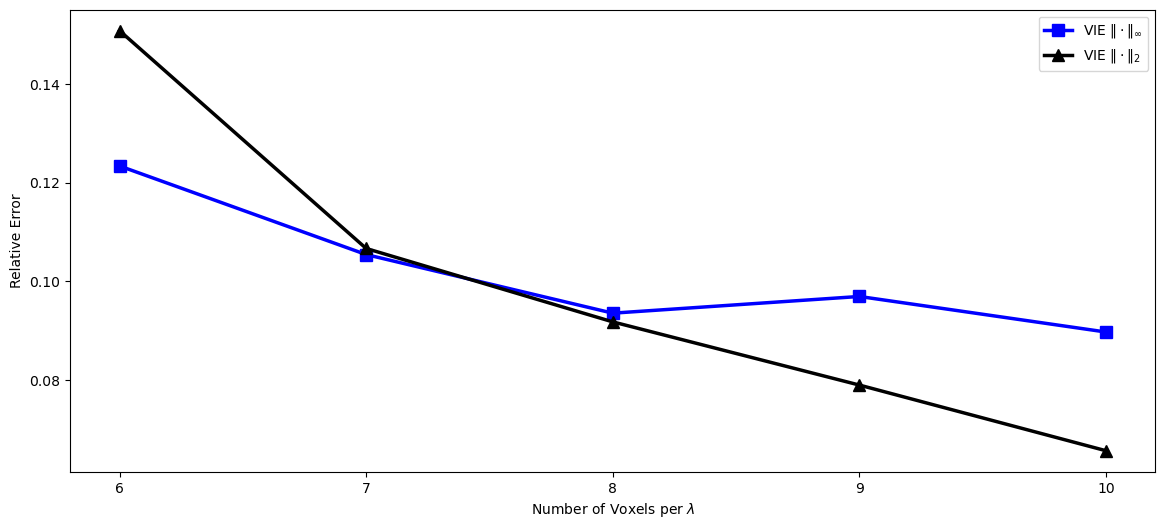

In [8]:
from matplotlib.ticker import MaxNLocator

num_vox = data_convergence['element_per_wavelength']
inf_err = data_convergence['error_rel_linf']
frb_err = data_convergence['error_rel_l2']


ax = plt.figure(figsize=(14, 6)).gca()

ax.plot(num_vox, inf_err, 'bs-', label='VIE $\|\cdot\|_\infty$', linewidth=2.5, markersize=8)
ax.plot(num_vox, frb_err, 'k^-', label='VIE $\|\cdot\|_2$', linewidth=2.5, markersize=8)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.xlabel(r'Number of Voxels per $\lambda$')
plt.ylabel('Relative Error')
plt.legend()

plt.show()

## Visualize convergence from data

The convergence test was performed on a powerful compute node and the results stored in the `data` folder. Let us load them and visualize the convergence plot.

In [2]:
"""
Convergence Plot from data
"""

num_vox = []
frb_err = []
inf_err = []


for i in range(5, 21):
    try:
        data_benchmark = np.load(f"data/benchmark_num_elem_{i}.npy", allow_pickle=True).item()
        num_vox.append(data_benchmark['num_elem'])
        frb_err.append(data_benchmark['error_rel_l2'])
        inf_err.append(data_benchmark['error_rel_linf'])
    except FileNotFoundError:
        print(f"File for N_elem={i} not found, skipping.")

num_vox = np.array(num_vox)
frb_err = np.array(frb_err)
inf_err = np.array(inf_err)

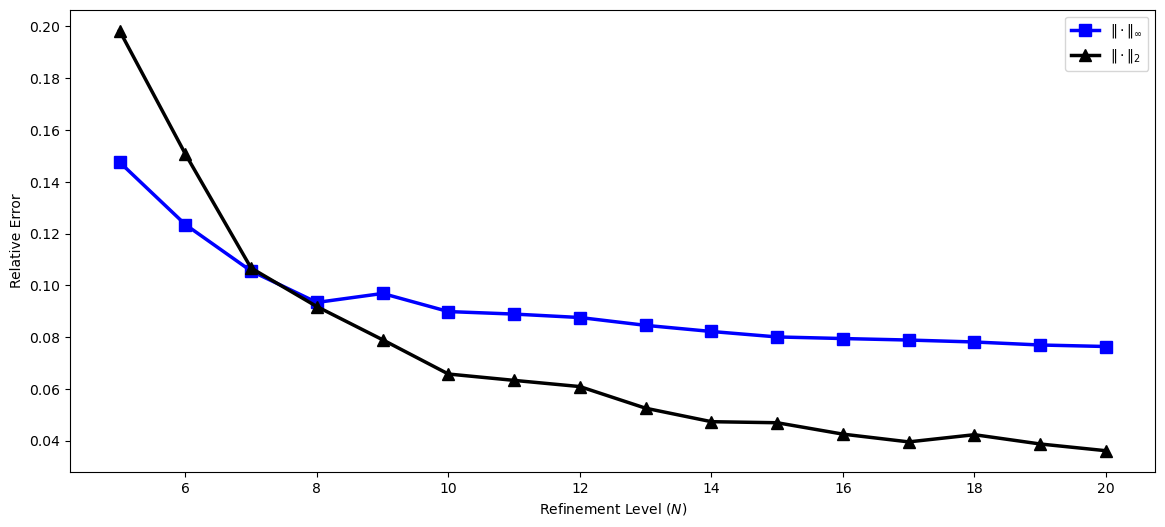

In [3]:
ax = plt.figure(figsize=(14, 6)).gca()

ax.plot(num_vox, inf_err, 'bs-', label=r'$\|\cdot\|_\infty$', linewidth=2.5, markersize=8)
ax.plot(num_vox, frb_err, 'k^-', label=r'$\|\cdot\|_2$', linewidth=2.5, markersize=8)

from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.xlabel(r'Refinement Level $(N)$')
plt.ylabel('Relative Error')
plt.legend()

plt.show()